# 502: Overshoot Quantification (Peak vs. Net-Zero-CO2 Timing)

Produces two supplementary figures characterising post-NZCO2 overshoot behavior,
using the p17/p50/p83 quantile trajectories (`individual_runs_quantiles_anthropogenic.csv`)
across the four pathway groups.

Outputs:
- `502_SFigure_3.png`
- `502_SFigure_4.png`
- `502_ZEC50_vs_peak_timing.png`

In [9]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dotenv.load_dotenv()

True

In [10]:
# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)


## Load Quantile Trajectory Data

Loads the full-scale p17/p50/p83 quantile trajectories
(`individual_runs_quantiles_anthropogenic.csv`) and builds `quantile_df_extended` -
all four scenario groups, each row carrying its own NZCO2 year, quantile-trajectory 
peak year/value, and post-NZCO2 GSAT change - same classification and derivation 501 uses.


In [11]:
quantile_df_raw = pd.read_csv(OUTPUT_FOLDER / "individual_runs_quantiles_anthropogenic.csv")
year_cols_q = [c for c in quantile_df_raw.columns if c.isdigit()]

netzero_timings_502 = pd.read_csv(OUTPUT_FOLDER / "101_netzero_timings.csv")
netzero_lookup_502 = netzero_timings_502.set_index(["model", "scenario"])["year_netzero_co2"].to_dict()
year_col_positions_502 = {int(c): i for i, c in enumerate(year_cols_q)}

# Classify into the four scenario groups
quantile_df_extended = quantile_df_raw.copy()
quantile_df_extended["scenario_group"] = quantile_df_extended["scenario"].apply(
    lambda x: "Stylised Variants (NZCO2-hold)" if "NZCO2" in x
    else ("Stylised Variants (NZGHG-hold)" if "NZKyoto" in x else "Scenarios (NZCO2)")
)
nzkyoto_combos_502 = set(
    quantile_df_extended[quantile_df_extended["scenario_group"] == "Stylised Variants (NZGHG-hold)"]
    .assign(scenario_key=lambda d: d["scenario"].str.replace("_NZKyoto", "", regex=False))
    [["model", "scenario_key"]]
    .itertuples(index=False, name=None)
)
base_df_502 = quantile_df_extended[quantile_df_extended["scenario_group"] == "Scenarios (NZCO2)"]
mask_502 = base_df_502.apply(lambda r: (r["model"], r["scenario"]) in nzkyoto_combos_502, axis=1)
base_nzghg_502 = base_df_502[mask_502].copy()
base_nzghg_502["scenario_group"] = "Scenarios (NZGHG)"
quantile_df_extended = pd.concat([quantile_df_extended, base_nzghg_502], ignore_index=True)

quantile_df_extended["base_scenario"] = (
    quantile_df_extended["scenario"].str.replace("_NZCO2", "", regex=False).str.replace("_NZKyoto", "", regex=False)
)
quantile_df_extended["year_netzero_co2"] = quantile_df_extended.apply(
    lambda r: netzero_lookup_502.get((r["model"], r["base_scenario"])), axis=1
)
quantile_df_extended = quantile_df_extended[quantile_df_extended["year_netzero_co2"].notna()].copy()
quantile_df_extended["year_netzero_co2"] = quantile_df_extended["year_netzero_co2"].astype(int)

quantile_df_extended["quantile_peak_year"] = quantile_df_extended[year_cols_q].idxmax(axis=1).astype(int)
quantile_df_extended["delta_timing_quantile"] = quantile_df_extended["year_netzero_co2"] - quantile_df_extended["quantile_peak_year"]

year_values_ext = quantile_df_extended[year_cols_q].values
row_positions_ext = quantile_df_extended["year_netzero_co2"].map(year_col_positions_502).values
quantile_df_extended["quantile_at_netzero_co2"] = year_values_ext[np.arange(len(year_values_ext)), row_positions_ext]
quantile_df_extended["quantile_at_2100"] = quantile_df_extended["2100"]
quantile_df_extended["delta_netzero_co2"] = quantile_df_extended["quantile_at_2100"] - quantile_df_extended["quantile_at_netzero_co2"]

group_counts_502 = (
    quantile_df_extended
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .size()
)
print(group_counts_502)


scenario_group
Scenarios (NZCO2)                 784
Scenarios (NZGHG)                 387
Stylised Variants (NZCO2-hold)    784
Stylised Variants (NZGHG-hold)    387
dtype: int64


## Figure: NZCO2 Year Minus Peak GSAT Year, Hatched by Criterion

For each scenario group, the p17/p50/p83 quantile trajectories' (NZCO2 year minus
peak GSAT year), with each bar subdivided by which 501 criterion the scenarios in
it satisfy (no further warming / peak-and-decline / ongoing warming), shown via
hatch pattern.


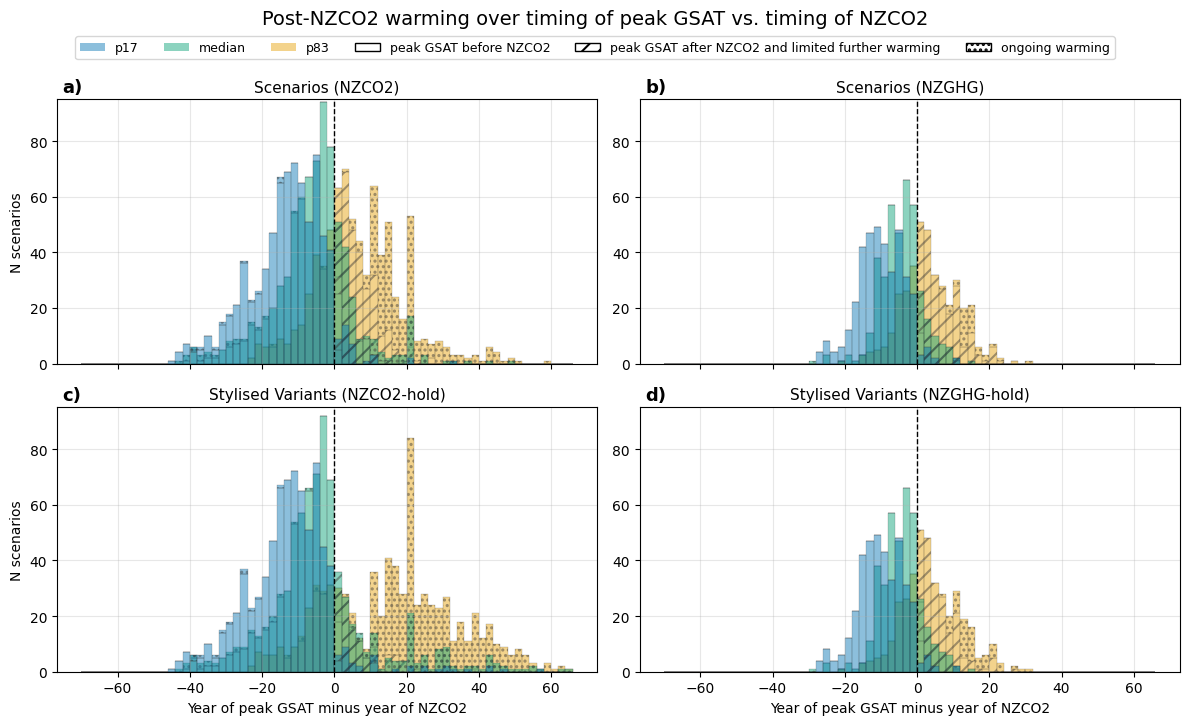

In [12]:
# Colorblind-safe palette (Okabe-Ito): blue, orange, bluish-green - distinguishable
# under all common types of color vision deficiency.
COLOR_P17 = "#0072B2"  # blue (cool)
COLOR_P50 = "#009E73"  # bluish-green (median)
COLOR_P83 = "#E69F00"  # orange (warm)

BIN_WIDTH = 2
BINS = range(-70, 65, BIN_WIDTH)

QUANTILE_LEVELS_PLOT = [
    (5/6, "p83", COLOR_P83),
    (0.5, "p50", COLOR_P50),
    (1/6, "p17", COLOR_P17),
]
CRITERION_HATCHES = [
    ("no_further_warming", ""),
    ("peak_and_decline", "//"),
    ("ongoing_warming", "..."),
]

bin_edges = np.array(list(BINS) + [list(BINS)[-1] + BIN_WIDTH])
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

from matplotlib.patches import Patch

plt.rcParams["hatch.linewidth"] = 1.5


def plot_timing_histogram(ax, group, title):
    for q, label, color in QUANTILE_LEVELS_PLOT:
        sub = quantile_df_extended[
            (quantile_df_extended["scenario_group"] == group)
            & (quantile_df_extended["quantile"].round(4) == round(q, 4))
        ].copy()
        peak_before = sub["quantile_peak_year"] <= sub["year_netzero_co2"]
        sub["no_further_warming"] = peak_before & (sub["delta_netzero_co2"] <= 0)
        sub["peak_and_decline"] = (~peak_before) & (sub["delta_netzero_co2"] <= 0)
        sub["ongoing_warming"] = ~(sub["no_further_warming"] | sub["peak_and_decline"])

        bottom = np.zeros(len(bin_centers))
        for crit, hatch in CRITERION_HATCHES:
            # Flipped sign: x-axis is now "year of peak GSAT minus year of NZCO2"
            # (positive = peak after NZCO2), not the other way around.
            vals = -sub.loc[sub[crit], "delta_timing_quantile"]
            counts, _ = np.histogram(vals, bins=bin_edges)
            ax.bar(bin_centers, counts, bottom=bottom, width=BIN_WIDTH, color=color, alpha=0.45,
                   edgecolor="#383636", linewidth=0.3, hatch=hatch)
            bottom += counts

    ax.axvline(x=0, linestyle="--", color="black", linewidth=1)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=False)

group_panels = [
    ("Scenarios (NZCO2)", "Scenarios (NZCO2)"),
    ("Scenarios (NZGHG)", "Scenarios (NZGHG)"),
    ("Stylised Variants (NZCO2-hold)", "Stylised Variants (NZCO2-hold)"),
    ("Stylised Variants (NZGHG-hold)", "Stylised Variants (NZGHG-hold)"),
]

for ax, (group, title) in zip(axes.flatten(), group_panels):
    plot_timing_histogram(ax, group, title)
    ax.set_ylim(0,95)

for ax in axes[1, :]:
    ax.set_xlabel("Year of peak GSAT minus year of NZCO2")

for ax in axes[:, 0]:
    ax.set_ylabel("N scenarios")

legend_elements = [
    Patch(facecolor=COLOR_P17, alpha=0.45, label="p17"),
    Patch(facecolor=COLOR_P50, alpha=0.45, label="median"),
    Patch(facecolor=COLOR_P83, alpha=0.45, label="p83"),
    Patch(facecolor="white", edgecolor="black", hatch="", label="peak GSAT before NZCO2"),
    Patch(facecolor="white", edgecolor="black", hatch="//", label="peak GSAT after NZCO2 and limited further warming"),
    Patch(facecolor="white", edgecolor="black", hatch="...", label="ongoing warming"),
]
fig.legend(handles=legend_elements, ncol=6, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, 1.0))

labels_ab = ["a)", "b)", "c)", "d)"]
for ax, label in zip(axes.flatten(), labels_ab):
    ax.annotate(label, xy=(0.01, 1.08), xycoords="axes fraction",
                fontsize=13, fontweight="bold", va="top", ha="left")

fig.suptitle("Post-NZCO2 warming over timing of peak GSAT vs. timing of NZCO2", fontsize=14, y=1.03)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "502_SFigure_3.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure: Overshoot Duration vs. Peak-Overshoot Magnitude, Colored by Mean ODY


For peak-and-decline pathways, evaluated fresh per quantile level:
overshoot duration (years the trajectory sits above its own NZCO2-year GSAT level)
vs. peak-overshoot magnitude relative to the NZCO2-year GSAT level 
(peak GSAT minus GSAT(NZCO2), colored by mean ODY (overshoot degree-years, same definition
as `500c_calculate_ody.py` applied to the quantile trajectory). Cell opacity encodes
how many scenarios back each bin, so sparse bins read as less certain.

In [13]:
from scipy.stats import binned_statistic_2d
from matplotlib.colors import Normalize

year_cols_int_hm = np.array([int(y) for y in year_cols_q])
quantile_panels = [(1/6, "p17"), (0.5, "median"), (5/6, "p83")]
CMAP_ODY = "plasma"

# Overshoot duration / ODY / absolute peak GSAT, computed directly on each quantile
# trajectory - same definition as 500c_calculate_ody.py (excess above the member's
# own NZCO2-year baseline, summed/counted over [NZCO2 year, 2100]), applied here to
# the p17/p50/p83 trajectories rather than real ensemble members.
values_ext_hm = quantile_df_extended[year_cols_q].values
baseline_ext_hm = quantile_df_extended["quantile_at_netzero_co2"].values.reshape(-1, 1)
nz_year_ext_hm = quantile_df_extended["year_netzero_co2"].values.reshape(-1, 1)

window_mask_ext_hm = (year_cols_int_hm.reshape(1, -1) >= nz_year_ext_hm) & (year_cols_int_hm.reshape(1, -1) <= 2100)
excess_ext_hm = np.where(window_mask_ext_hm, np.clip(values_ext_hm - baseline_ext_hm, 0, None), 0.0)

quantile_df_extended["overshoot_duration"] = (excess_ext_hm > 0).sum(axis=1)
quantile_df_extended["ODY_quantile"] = excess_ext_hm.sum(axis=1)
quantile_df_extended["peak_gsat_abs"] = values_ext_hm.max(axis=1)

GROUPS_ORDER = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

per_cell_hm = {}
for group in GROUPS_ORDER:
    group_df = quantile_df_extended[quantile_df_extended["scenario_group"] == group]
    for q, label in quantile_panels:
        sub_q = group_df[group_df["quantile"].round(4) == round(q, 4)].copy()
        peak_before = sub_q["quantile_peak_year"] <= sub_q["year_netzero_co2"]
        sub_q["peak_and_decline"] = (~peak_before) & (sub_q["delta_netzero_co2"] <= 0)
        per_cell_hm[(group, label)] = sub_q[sub_q["peak_and_decline"]]

all_crit_c_ext = pd.concat(per_cell_hm.values())
duration_max_ext = all_crit_c_ext["overshoot_duration"].max()
gsat_min_ext = all_crit_c_ext["peak_gsat_abs"].min()
gsat_max_ext = all_crit_c_ext["peak_gsat_abs"].max()
vmax_ody_ext = all_crit_c_ext["ODY_quantile"].quantile(0.98)

duration_bins_ext = np.arange(0, duration_max_ext + 5, 4)
gsat_bins_ext = np.linspace(gsat_min_ext, gsat_max_ext, 20)

# Cell POPULATION is encoded via alpha: a bin's mean-ODY color looks identical
# whether it rests on 1 scenario or 40, so without some signal in the same visual
# object a sparse, noisy bin reads as just as trustworthy as a well-supported one.
# Alpha saturates at the 90th percentile of per-bin counts pooled across every panel
# - one shared scale, so a whole group with little data overall correctly renders
# fainter throughout, not just individual bins within it.
norm_ody = Normalize(vmin=0, vmax=vmax_ody_ext)
cmap_ody = plt.get_cmap(CMAP_ODY)
MIN_ALPHA = 0.15

cell_stats = {}
all_counts_list = []
for group in GROUPS_ORDER:
    for q, label in quantile_panels:
        data = per_cell_hm[(group, label)]
        if len(data) == 0:
            cell_stats[(group, label)] = (None, None)
            continue
        mean_stat, xedges, yedges, _ = binned_statistic_2d(
            data["overshoot_duration"], data["peak_gsat_abs"], data["ODY_quantile"],
            statistic="mean", bins=[duration_bins_ext, gsat_bins_ext],
        )
        count_stat, _, _, _ = binned_statistic_2d(
            data["overshoot_duration"], data["peak_gsat_abs"], data["ODY_quantile"],
            statistic="count", bins=[duration_bins_ext, gsat_bins_ext],
        )
        cell_stats[(group, label)] = (mean_stat, count_stat)
        all_counts_list.append(count_stat[count_stat > 0])

alpha_saturation_n = np.percentile(np.concatenate(all_counts_list), 90)

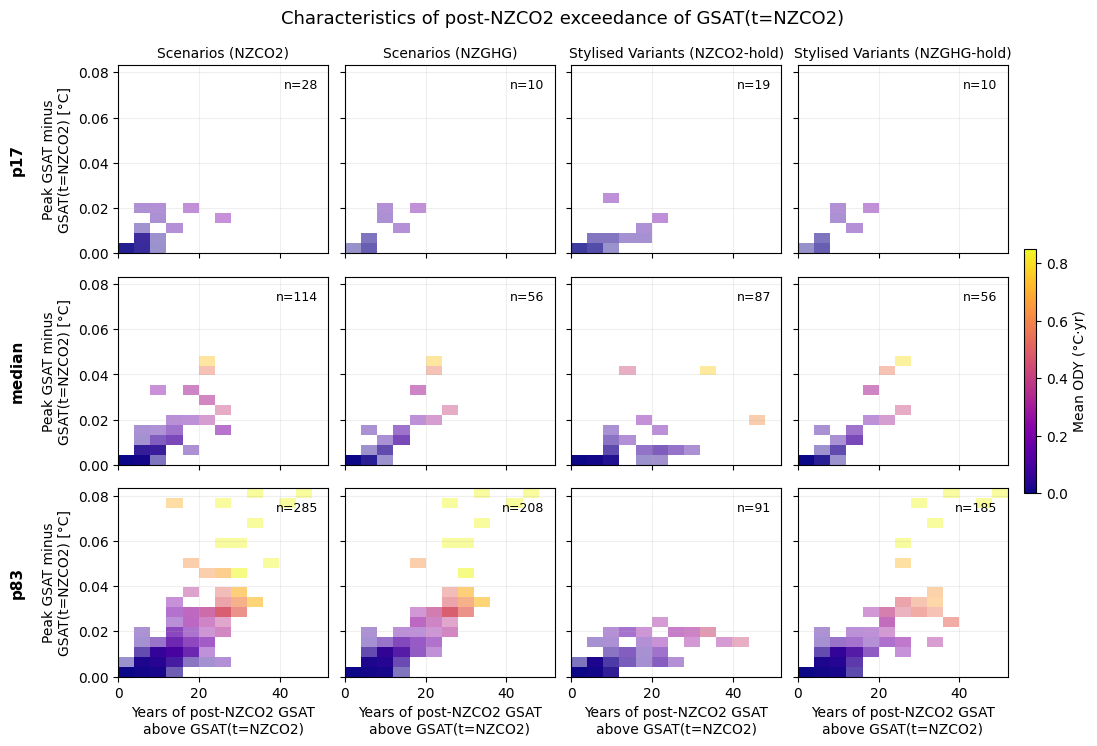

In [14]:
quantile_df_extended["peak_overshoot"] = values_ext_hm.max(axis=1) - baseline_ext_hm.flatten()

per_cell_hm_rel = {}
for group in GROUPS_ORDER:
    group_df = quantile_df_extended[quantile_df_extended["scenario_group"] == group]
    for q, label in quantile_panels:
        sub_q = group_df[group_df["quantile"].round(4) == round(q, 4)].copy()
        peak_before = sub_q["quantile_peak_year"] <= sub_q["year_netzero_co2"]
        sub_q["peak_and_decline"] = (~peak_before) & (sub_q["delta_netzero_co2"] <= 0)
        per_cell_hm_rel[(group, label)] = sub_q[sub_q["peak_and_decline"]]

all_crit_c_rel = pd.concat(per_cell_hm_rel.values())
duration_max_rel = all_crit_c_rel["overshoot_duration"].max()
magnitude_max_rel = all_crit_c_rel["peak_overshoot"].max()
vmax_ody_rel = all_crit_c_rel["ODY_quantile"].quantile(0.98)

duration_bins_rel = np.arange(0, duration_max_rel + 5, 4)
magnitude_bins_rel = np.linspace(0, magnitude_max_rel, 20)

norm_ody_rel = Normalize(vmin=0, vmax=vmax_ody_rel)

cell_stats_rel = {}
all_counts_list_rel = []
for group in GROUPS_ORDER:
    for q, label in quantile_panels:
        data = per_cell_hm_rel[(group, label)]
        if len(data) == 0:
            cell_stats_rel[(group, label)] = (None, None)
            continue
        mean_stat, xedges, yedges, _ = binned_statistic_2d(
            data["overshoot_duration"], data["peak_overshoot"], data["ODY_quantile"],
            statistic="mean", bins=[duration_bins_rel, magnitude_bins_rel],
        )
        count_stat, _, _, _ = binned_statistic_2d(
            data["overshoot_duration"], data["peak_overshoot"], data["ODY_quantile"],
            statistic="count", bins=[duration_bins_rel, magnitude_bins_rel],
        )
        cell_stats_rel[(group, label)] = (mean_stat, count_stat)
        all_counts_list_rel.append(count_stat[count_stat > 0])

alpha_saturation_n_rel = np.percentile(np.concatenate(all_counts_list_rel), 90)

fig, axes = plt.subplots(len(quantile_panels), len(GROUPS_ORDER), figsize=(3 * len(GROUPS_ORDER), 2.4 * len(quantile_panels)), sharex=True, sharey=True)

for row, (q, label) in enumerate(quantile_panels):
    for col, group in enumerate(GROUPS_ORDER):
        ax = axes[row, col]
        mean_stat, count_stat = cell_stats_rel[(group, label)]
        if mean_stat is not None:
            rgba = cmap_ody(norm_ody_rel(mean_stat.T))
            alpha = MIN_ALPHA + (1 - MIN_ALPHA) * np.sqrt(np.clip(count_stat.T / alpha_saturation_n_rel, 0, 1))
            alpha[count_stat.T == 0] = 0.0
            rgba[..., 3] = alpha
            ax.imshow(
                rgba, origin="lower", interpolation="nearest",
                extent=[duration_bins_rel[0], duration_bins_rel[-1], magnitude_bins_rel[0], magnitude_bins_rel[-1]],
                aspect="auto",
            )
        ax.grid(alpha=0.2)
        ax.annotate(f"n={len(per_cell_hm_rel[(group, label)])}", xy=(0.95, 0.93), xycoords="axes fraction", ha="right", va="top", fontsize=9)
        if row == 0:
            ax.set_title(group, fontsize=10)
        if row == len(quantile_panels) - 1:
            ax.set_xlabel("Years of post-NZCO2 GSAT\nabove GSAT(t=NZCO2)")

for row, (q, label) in enumerate(quantile_panels):
    axes[row, 0].set_ylabel("Peak GSAT minus\nGSAT(t=NZCO2) [°C]")
    axes[row, 0].annotate(
        label, xy=(-0.48, 0.5), xycoords="axes fraction",
        rotation=90, va="center", ha="center", fontsize=11, fontweight="bold",
    )

plt.tight_layout()

sm_rel = plt.cm.ScalarMappable(cmap=cmap_ody, norm=norm_ody_rel)
sm_rel.set_array([])
fig.colorbar(sm_rel, ax=axes, label="Mean ODY (°C·yr)", shrink=0.4, pad=0.015)

# Cell opacity ∝ sqrt(scenario count), saturating at 6 scenarios/bin

fig.suptitle(
    "Characteristics of post-NZCO2 exceedance of GSAT(t=NZCO2)",
    y=1.03, x=0.47, fontsize=13
)

plt.savefig(PLOT_FOLDER / "502_SFigure_4.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure: ZEC50 vs. Peak Timing, Same X-Axis as `502_SFigure_3.png`

Everything ranked by GSAT: for each scenario, its 600 real members are ranked by
their own 2100 GSAT value (`GSAT|ANTHROPOGENIC|2100` - consistent with 505's
cross-quantile comparison, which found this ranking criterion keeps absolute GSAT
levels monotonic across quantile levels, unlike ranking by peak GSAT or by the
NZCO2-to-2100 delta itself), and the real member sitting at each of the
p17/median/p83 ranks (nearest-rank, not interpolated) is picked out. That same
member's own peak-timing and ZEC$_{50}$ are then reported together - one
internally-consistent real member per quantile group, not two independently-ranked
marginal distributions (which is what the first version of this figure did).


In [15]:
MANIFEST_ID_502 = "regenerated"
metrics_df_502 = pd.read_csv(OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID_502}.csv", index_col=0)

# Per-member ZEC50 (same definition as 503/504): CO2_NZCO2's delta rescaled from each
# member's own NZCO2-to-2100 window to a standardized 50-year window.
metrics_df_502["ZEC50"] = (
    metrics_df_502["GSAT|CO2_NZCO2|delta_netzero_co2"] * 50 / (2100 - metrics_df_502["year_netzero_co2"])
)
# Real per-member peak timing (not a quantile trajectory) - year_netzero_co2 is the
# same for every member of a scenario (it's an emissions-pathway property), but
# peak_year is genuinely per-member (climate-response dependent).
metrics_df_502["peak_minus_nzco2"] = metrics_df_502["peak_year"] - metrics_df_502["year_netzero_co2"]

QUANTILE_RANKS = {"p17": 1 / 6, "p50": 0.5, "p83": 5 / 6}


def pick_member_at_rank(group_df, q):
    """The real member nearest the q-th rank of 2100 GSAT value (nearest-rank, not
    interpolated) - returns an actual ensemble member row, not a synthetic
    interpolated value, so every quantity read off it belongs to one real member.
    Ranked by 2100 GSAT rather than peak GSAT or the NZCO2-to-2100 delta - same
    choice as 505's cross-quantile comparison, which found this keeps absolute GSAT
    levels monotonic across quantile levels in every scenario group."""
    sorted_df = group_df.sort_values("GSAT|ANTHROPOGENIC|2100")
    idx = round(q * (len(sorted_df) - 1))
    return sorted_df.iloc[idx]


zec50_rows = []
for (model, scenario, scenario_group), gdf in metrics_df_502.groupby(["model", "scenario", "scenario_group"]):
    for label, q in QUANTILE_RANKS.items():
        member = pick_member_at_rank(gdf, q)
        zec50_rows.append({
            "model": model, "scenario": scenario, "scenario_group": scenario_group,
            "quantile_label": label,
            "peak_minus_nzco2": member["peak_minus_nzco2"],
            "ZEC50_q": member["ZEC50"],
            # Table 1's criterion a) - does THIS real member's own GSAT(2100) sit at
            # or below its own GSAT(NZCO2) - evaluated per-member, consistent with
            # the project's member-level-delta-first convention (not re-derived from
            # a separately-aggregated quantile statistic).
            "returns_to_nzco2": member["GSAT|ANTHROPOGENIC|delta_netzero_co2"] <= 0,
        })

zec50_plot_df = pd.DataFrame(zec50_rows)
print(f"Built {len(zec50_plot_df)} (scenario, quantile level) pairs, one real member each")
print(f"Share returning to/below NZCO2 GSAT: {zec50_plot_df['returns_to_nzco2'].mean():.1%}")

Built 7026 (scenario, quantile level) pairs, one real member each
Share returning to/below NZCO2 GSAT: 81.7%


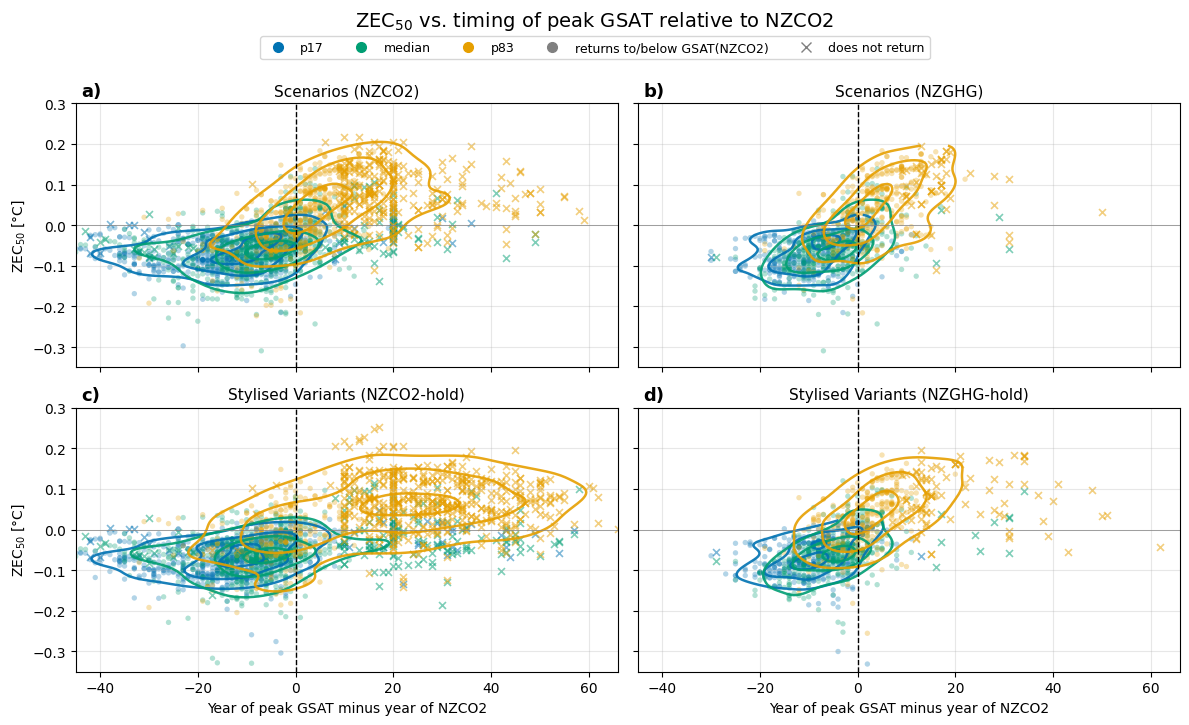

In [16]:
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde


def add_2d_density_contour(ax, x, y, color, n_levels=3):
    """Overlay 2D KDE contour outlines on the same axis as a scatter plot, so the
    shape/density of each overlapping quantile-level group is still readable even
    where points pile up on top of each other."""
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    zz = np.reshape(kde(np.vstack([xx.ravel(), yy.ravel()])), xx.shape)
    # Levels as fractions of the peak density, so the outermost contour traces
    # roughly where the bulk of the group sits rather than its sparse tails.
    levels = np.linspace(zz.max() * 0.15, zz.max() * 0.85, n_levels)
    ax.contour(xx, yy, zz, levels=levels, colors=[color], linewidths=1.8, alpha=0.9)


fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)

for ax, (group, title) in zip(axes.flatten(), group_panels):
    sub = zec50_plot_df[zec50_plot_df["scenario_group"] == group]
    for label, color in [("p17", COLOR_P17), ("p50", COLOR_P50), ("p83", COLOR_P83)]:
        s = sub[sub["quantile_label"] == label]
        # Marker shape encodes Table 1 criterion a) for THIS member: dot = returns to
        # or below GSAT(NZCO2) by 2100; x = does not. Density contour is computed on
        # all points of this quantile level together (not split by marker), so it
        # still reflects the full distribution.
        s_returns = s[s["returns_to_nzco2"]]
        s_no_return = s[~s["returns_to_nzco2"]]
        ax.scatter(s_returns["peak_minus_nzco2"], s_returns["ZEC50_q"], color=color,
                   alpha=0.3, s=15, edgecolors="none", marker="o")
        ax.scatter(s_no_return["peak_minus_nzco2"], s_no_return["ZEC50_q"], color=color,
                   alpha=0.5, s=25, marker="x", linewidths=1.2)
        add_2d_density_contour(ax, s["peak_minus_nzco2"].values, s["ZEC50_q"].values, color)
    ax.axvline(x=0, linestyle="--", color="black", linewidth=1)
    ax.axhline(y=0, linestyle="-", color="gray", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)

# Clipped to where ~99% of points and the density contours actually sit - a few
# individual-member outliers (short NZCO2-to-2100 windows amplify per-member noise
# when rescaled to the standardized 50-year ZEC50 metric, e.g. a 25-year window
# doubles it) otherwise stretch the shared y-axis into mostly empty space.
for ax in axes.flatten():
    ax.set_ylim(-0.35, 0.3)

for ax in axes[1, :]:
    ax.set_xlabel("Year of peak GSAT minus year of NZCO2")

for ax in axes[:, 0]:
    ax.set_ylabel("ZEC$_{50}$ [°C]")

legend_elements = [
    Line2D([0], [0], marker="o", linestyle="none", color=COLOR_P17, label="p17", markersize=7),
    Line2D([0], [0], marker="o", linestyle="none", color=COLOR_P50, label="median", markersize=7),
    Line2D([0], [0], marker="o", linestyle="none", color=COLOR_P83, label="p83", markersize=7),
    Line2D([0], [0], marker="o", linestyle="none", color="gray", label="returns to/below GSAT(NZCO2)", markersize=7),
    Line2D([0], [0], marker="x", linestyle="none", color="gray", label="does not return", markersize=7),
]
fig.legend(handles=legend_elements, ncol=5, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, 1.0))

labels_ab = ["a)", "b)", "c)", "d)"]
for ax, label in zip(axes.flatten(), labels_ab):
    ax.annotate(label, xy=(0.01, 1.08), xycoords="axes fraction",
                fontsize=13, fontweight="bold", va="top", ha="left")

fig.suptitle("ZEC$_{50}$ vs. timing of peak GSAT relative to NZCO2", fontsize=14, y=1.03)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "502_ZEC50_vs_peak_timing.png", dpi=300, bbox_inches="tight")
plt.show()